In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2, invgamma, norm, multivariate_normal
from sklearn.preprocessing import StandardScaler
from statsmodels.graphics.tsaplots import plot_acf
import pymc as pm 
import arviz as az

In [3]:
df = pd.read_csv("cleanedbaysian.csv")

# Use delay columns instead of counts
features = [
   "arr_flights",      
    "arr_del15",        
    "arr_cancelled",    
    "arr_diverted",     
    "month"             
]

target = "arr_delay"

# Drop missing values
df = df[features + [target]].dropna()

# Remove outliers using IQR (there are outliers messing up current data)
Q1 = df[target].quantile(0.25)
Q3 = df[target].quantile(0.75)
IQR = Q3 - Q1
df = df[(df[target] >= Q1 - 1.5*IQR) & (df[target] <= Q3 + 1.5*IQR)]

# Subsample (dataset too large)
N = 1000
df = df.sample(n=N, random_state=42)  

X = df[features].values
y = df[target].values

In [4]:
print(df["arr_delay"].describe())


count    1000.000000
mean     1355.438000
std      1475.791309
min         0.000000
25%       307.750000
50%       795.000000
75%      1861.000000
max      6646.000000
Name: arr_delay, dtype: float64


In [50]:
# scale
X_mean = X.mean(axis=0)
X_std = X.std(axis=0)
X_scaled = (X - X_mean) / X_std

print(X_scaled.shape, y.shape)


(1000, 5) (1000,)


In [51]:
with pm.Model() as model:

    # Priors for coefficients
    beta = pm.Normal("beta", mu=0, sigma=1, shape=X_scaled.shape[1])
    
    # Prior for intercept
    intercept = pm.Normal("intercept", mu=0, sigma=1)
    
    # Prior for noise
    sigma = pm.HalfNormal("sigma", sigma=1)
    
    # Expected value
    mu = intercept + pm.math.dot(X_scaled, beta)
    
    # Likelihood
    y_obs = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=y)
    
    # Sampling (posterior)
    trace = pm.sample(2000, tune=1000, target_accept=0.9, random_seed=42)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta, intercept, sigma]


/Users/deekshitamadhalam/anaconda3/envs/bayes_clean/lib/python3.11/site-packages/rich/live.py:260: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 3 seconds.


In [52]:
# Summary of posterior
summary = az.summary(trace)
print(summary)

              mean     sd   hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
beta[0]     16.685  1.003   14.792   18.564      0.009    0.012   11750.0   
beta[1]     21.973  0.984   20.074   23.735      0.009    0.012   13379.0   
beta[2]      5.184  0.993    3.283    7.015      0.009    0.012   12410.0   
beta[3]      3.804  0.995    1.947    5.682      0.009    0.012   12477.0   
beta[4]     -0.019  1.006   -1.947    1.782      0.009    0.012   12649.0   
intercept   21.656  1.009   19.762   23.537      0.009    0.011   12772.0   
sigma      248.167  0.502  247.219  249.089      0.004    0.006   12955.0   

           ess_tail  r_hat  
beta[0]      5710.0    1.0  
beta[1]      5777.0    1.0  
beta[2]      5800.0    1.0  
beta[3]      5844.0    1.0  
beta[4]      5273.0    1.0  
intercept    6033.0    1.0  
sigma        6411.0    1.0  


In [53]:
# Extract posterior means
beta_means = trace.posterior["beta"].mean(dim=["chain", "draw"]).values

for i, feature in enumerate(features):
    print(f"{feature}: {beta_means[i]}")

arr_flights: 16.68518578956318
arr_del15: 21.972816055610046
arr_cancelled: 5.184020137153382
arr_diverted: 3.8040733580464066
month: -0.01909235039757145


In [54]:
# Rank features
importance = pd.Series(beta_means, index=features)
importance = importance.sort_values(ascending=False)

print("Most important delay factors:")
print(importance)

Most important delay factors:
arr_del15        21.972816
arr_flights      16.685186
arr_cancelled     5.184020
arr_diverted      3.804073
month            -0.019092
dtype: float64


array([[<Axes: title={'center': 'beta\n0'}>,
        <Axes: title={'center': 'beta\n1'}>,
        <Axes: title={'center': 'beta\n2'}>],
       [<Axes: title={'center': 'beta\n3'}>,
        <Axes: title={'center': 'beta\n4'}>,
        <Axes: title={'center': 'intercept'}>],
       [<Axes: title={'center': 'sigma'}>, <Axes: >, <Axes: >]],
      dtype=object)

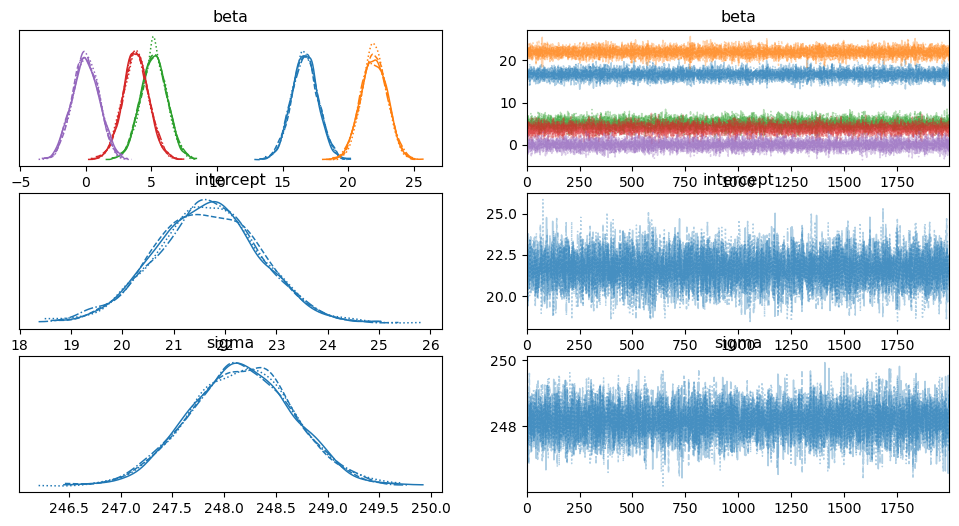

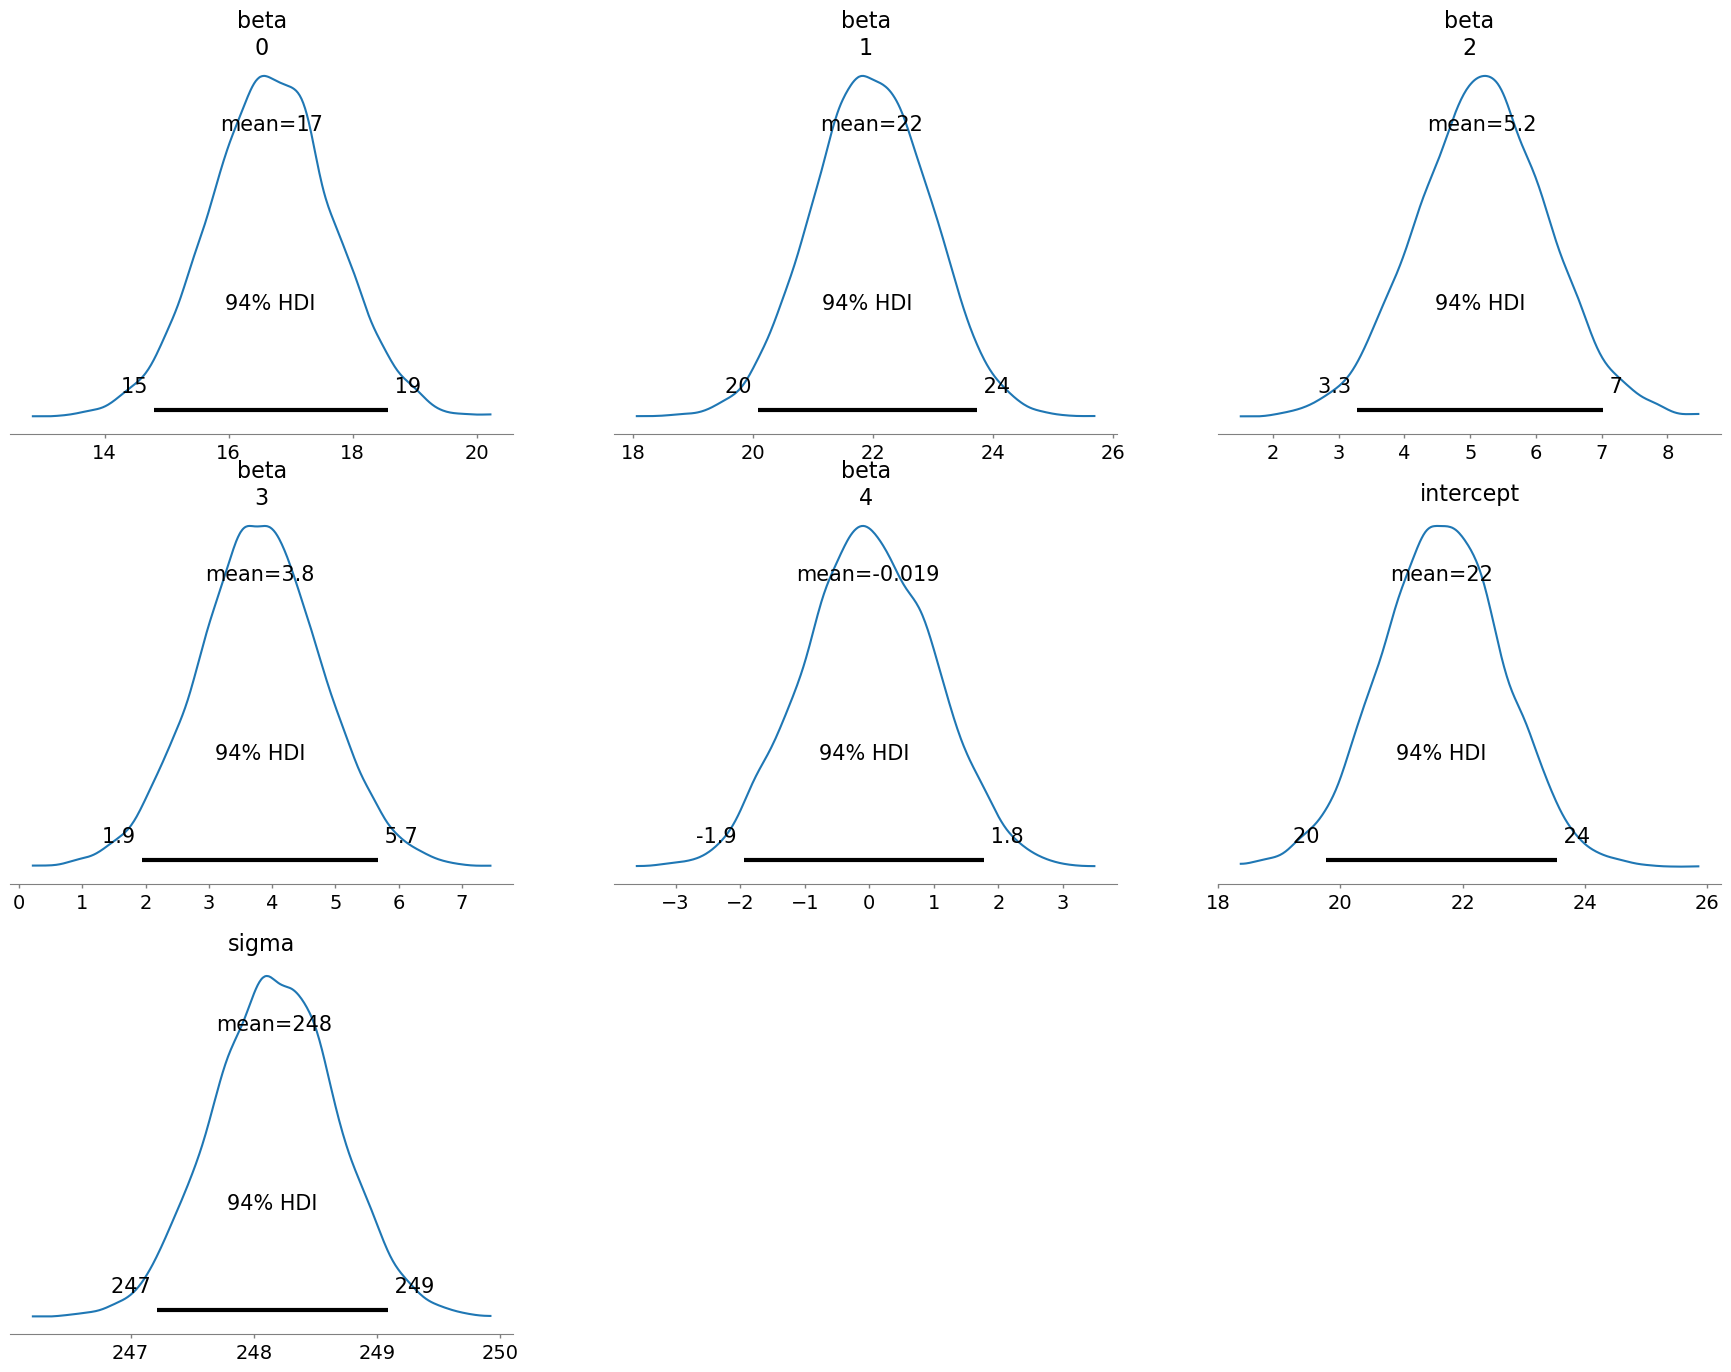

In [55]:
# Trace plots (check convergence)
az.plot_trace(trace)

# Posterior distributions
az.plot_posterior(trace)

Sampling: [y_obs]


/Users/deekshitamadhalam/anaconda3/envs/bayes_clean/lib/python3.11/site-packages/rich/live.py:260: UserWarning: 
install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

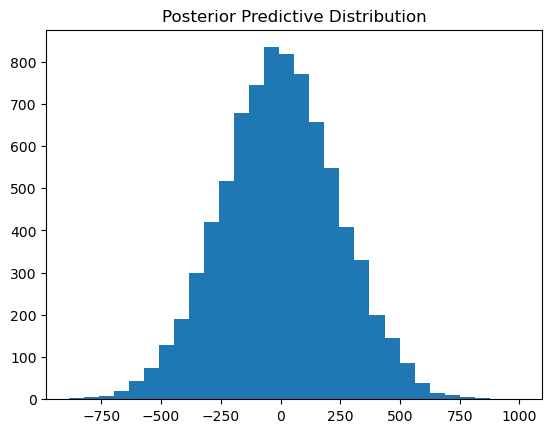

In [56]:
with model:
    ppc = pm.sample_posterior_predictive(trace, var_names=["y_obs"])

# Plot for observation
plt.hist(ppc.posterior_predictive['y_obs'][:,:,0].values.ravel(), bins=30)
plt.title("Posterior Predictive Distribution")
plt.show()

In [57]:
preds = ppc.posterior_predictive['y_obs'].values.ravel()
print("Predicted mean:", np.mean(preds))
print("Actual value:", y[0])

Predicted mean: 21.586049285982718
Actual value: 330.0


In [58]:
# Get posterior predictive mean for all observations
ppc_means = ppc.posterior_predictive['y_obs'].mean(dim=["chain", "draw"]).values

# RMSE
rmse = np.sqrt(np.mean((y - ppc_means)**2))
print("RMSE:", rmse)

RMSE: 1963.3272165329906


In [60]:
ss_res = np.sum((y - ppc_means)**2)
ss_tot = np.sum((y - np.mean(y))**2)
r2 = 1 - (ss_res / ss_tot)
print(f"R² Score: {r2 * 100:.2f}%")

R² Score: -77.16%
